# gLSTM Results

In [1]:
import os

import matplotlib.pyplot as plt

plt.style.use(os.path.join("figures", "matlab.mplstyle"))

import pandas as pd

from string import Template

from copy import deepcopy

from notebook_utils import *

In [2]:
MODEL_NAME = "gLSTM"
get_model_name = lambda model_name: "gLSTM" if "xlstm" in model_name.lower() else model_name

### RingTransfer

In [3]:
ring_transfer_models = ["GNN-xLSTM", "GNN-SSM", "GCN"]
ring_transfer_layers = [2, 4, 8, 16, 32, 64, 128, 192, 256, 320]

ring_transfer_df, failed_value_combinations = results_dirs_to_df(
    keywords_to_filepath=lambda model_name, layer_count: os.path.join(
        "results", "ring_transfer", f"ring-transfer-{model_name}-layers_{layer_count}"
    ),
    metric_name="accuracy",
    goal=lambda *_: max,
    model=ring_transfer_models,
    layers=ring_transfer_layers,
)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


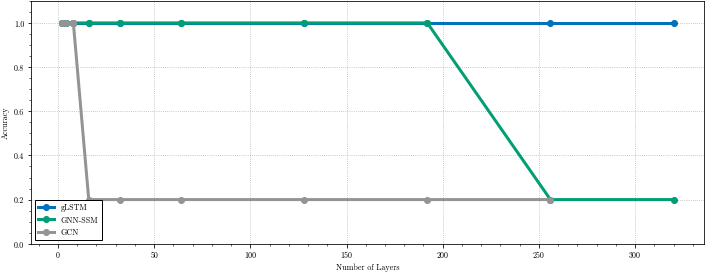

In [4]:
# Create a figure a single plot
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
# Plot each model
for model in ring_transfer_models:
    model_data = ring_transfer_df[ring_transfer_df["model"] == model]

    means = model_data.groupby("layers")["accuracy"].mean()
    stds = model_data.groupby("layers")["accuracy"].std()
    maxes = model_data.groupby("layers")["accuracy"].max()
    mins = model_data.groupby("layers")["accuracy"].min()

    # Plot mean line
    line = axes.plot(means.index, means.values, label=get_model_name(model), marker="o")[0]

    axes.fill_between(
        means.index, maxes.values, mins.values, alpha=0.1, color=line.get_color()
    )

axes.set_xlabel("Number of Layers")
axes.set_ylabel("Accuracy")
axes.set_ylim(0.0, 1.1)
axes.legend()
axes.grid(True)

plt.tight_layout()
plt.savefig(os.path.join("figures", "ring-transfer-accuracy.pdf"))
plt.show()

### NAR

This was getting too unweildy in the notebook, so I have moved this all to the `plot_all_nar_results` function in `notebook_utils.py`. The print statements provide some documentation for each component of that function.

## Real-World Datasets

### Graph Property Prediction

In [5]:
gpp_table_template = Template(
    r"""\begin{table*}[ht]
    \centering
    \caption{Mean and standard deviation of $\log_{10}(\text{MSE})$, averaged over 4 random weight initializations on the GPP tasks from \citet{Gravina2022AntiSymmetricDA}, from which we report baselines. See \Cref{apen:extended_gpp} for discussion of baseline choice. \textbf{Top} score in bold, \underline{second} underlined. Lower is better.}
    \label{tab:gpp_results}
    \begin{tabular}{lccc}
        \toprule
        \textbf{Method} & \textbf{Diam.} & \textbf{Ecc.} & \textbf{SSSP} \\
        \midrule
        GCN        & 0.742 ± 0.047 & 0.846 ± 0.003 & 0.950 ± 0.000 \\
        GAT        & 0.822 ± 0.075 & 0.791 ± 0.022 & 0.695 ± 0.150 \\
        GraphSAGE & 0.865 ± 0.40 & 0.286 ± 0.184 &  0.786 ± 0.021 \\
        GIN & 0.613 ± 0.099 & 0.950 ± 0.001  & -0.541 ± 0.419 \\
        GCNII & 0.529 ± 0.057 & 0.764 ± 0.036  & -1.132 ± 0.013 \\
        DGC & 0.603 ± 0.005 & 0.826 ± 0.003 & -0.148 ± 0.023 \\
        GRAND & 0.672 ± 0.049 & 0.660 ± 0.139 & -0.094 ± 0.340 \\
        A-DGN & \underline{-0.546 ± 0.033} & \underline{0.305 ± 0.118} & {\bf -3.402 ± 0.137} \\
        \midrule
        \modelname{} (ours) & $diam_mean ± $diam_std & $ecc_mean ± $ecc_std & $sssp_mean ± $sssp_std \\
        \bottomrule
    \end{tabular}
\end{table*}"""
)

In [6]:
gpp_df, failed_gpp_combinations = results_dirs_to_df(
    keywords_to_filepath=lambda dataset: os.path.join(
        "results", "gpp", f"gpp-{dataset}-GNN-xLSTM"
    ),
    metric_name="log_10_mse",
    goal=lambda _: min,
    dataset=["diam", "ecc", "sssp"],
)

In [7]:
diam_mean = gpp_df[gpp_df["dataset"] == "diam"]["log_10_mse"].mean()
diam_std = gpp_df[gpp_df["dataset"] == "diam"]["log_10_mse"].std()
ecc_mean = gpp_df[gpp_df["dataset"] == "ecc"]["log_10_mse"].mean()
ecc_std = gpp_df[gpp_df["dataset"] == "ecc"]["log_10_mse"].std()
sssp_mean = gpp_df[gpp_df["dataset"] == "sssp"]["log_10_mse"].mean()
sssp_std = gpp_df[gpp_df["dataset"] == "sssp"]["log_10_mse"].std()

gpp_substitution_dict = {
            "diam_mean": f'{diam_mean:.3f}',
            "diam_std": f'{diam_std:.3f}',
            "ecc_mean": f'{ecc_mean:.3f}',
            "ecc_std": f'{ecc_std:.3f}',
            "sssp_mean": f'{sssp_mean:.3f}',
            "sssp_std": f'{sssp_std:.3f}',
        }

print(
    gpp_table_template.safe_substitute(
        gpp_substitution_dict
    )
)

\begin{table*}[ht]
    \centering
    \caption{Mean and standard deviation of $\log_{10}(\text{MSE})$, averaged over 4 random weight initializations on the GPP tasks from \citet{Gravina2022AntiSymmetricDA}, from which we report baselines. See \Cref{apen:extended_gpp} for discussion of baseline choice. \textbf{Top} score in bold, \underline{second} underlined. Lower is better.}
    \label{tab:gpp_results}
    \begin{tabular}{lccc}
        \toprule
        \textbf{Method} & \textbf{Diam.} & \textbf{Ecc.} & \textbf{SSSP} \\
        \midrule
        GCN        & 0.742 ± 0.047 & 0.846 ± 0.003 & 0.950 ± 0.000 \\
        GAT        & 0.822 ± 0.075 & 0.791 ± 0.022 & 0.695 ± 0.150 \\
        GraphSAGE & 0.865 ± 0.40 & 0.286 ± 0.184 &  0.786 ± 0.021 \\
        GIN & 0.613 ± 0.099 & 0.950 ± 0.001  & -0.541 ± 0.419 \\
        GCNII & 0.529 ± 0.057 & 0.764 ± 0.036  & -1.132 ± 0.013 \\
        DGC & 0.603 ± 0.005 & 0.826 ± 0.003 & -0.148 ± 0.023 \\
        GRAND & 0.672 ± 0.049 & 0.660 ± 0.139 & -0.

### LRGB

In [8]:
lrgb_table_template = Template(
    r"""\begin{wraptable}{r}{0.5\textwidth} %[htbp]
    \centering
    \vspace{-0.45cm}
    \caption{Mean and standard deviation on LRGB \citep{Dwivedi2022LongRG}, averaged over four random weight initializations. Baselines from the LRGB reevaluation of \citet{Tonshoff2023WhereDT} and K-hop methods from \citet{Arroyo2025OnVG}. All methods adhere to a 500k parameter limit. \textbf{Top} score in bold, \underline{second} underlined.}
    \label{tab:lrgb_results}
    \addtolength{\tabcolsep}{-0.4em}
    \begin{tabular}{lcc}
        \toprule
        \textbf{Method} & \textbf{Peptides-Func} & \textbf{Peptides-Struct} \\
        \cmidrule(lr){2-3}
        & \textbf{AP ($\uparrow$)} & \textbf{MAE ($\downarrow$)} \\
        \midrule
        GCN & 0.6860±0.0050 & {\bf 0.2460±0.0007}  \\
        GatedGCN & 0.6765±0.0047 & 0.2477±0.0009 \\
        GINE & 0.6621±0.0067 & \underline{0.2473±0.0017} \\
        GPS & 0.6534±0.0091 & 0.2509±0.0014 \\
        \midrule
        \textit{K-hop methods} \\
        kGCN-SSM & \underline{0.6902±0.0022} & 0.2581±0.0003 \\
        DRew-GCN & {0.6804±0.0144} & 0.2766±0.0019 \\
        \midrule
        \modelname{} (ours) & $peptides_func_mean $\pm$ $peptides_func_std & $peptides_struct_mean $\pm$ $peptides_struct_std \\
        \bottomrule
    \end{tabular}
\end{wraptable}"""
)

In [9]:
lrgb_df, failed_lrgb_combinations = results_dirs_to_df(
    keywords_to_filepath=lambda dataset: os.path.join(
        "results", "lrgb", f"{dataset}-GNN-xLSTM-best_val"
    ),
    metric_name=lambda dataset: {
        "peptides-func": "ap",
        "peptides-struct": "mae",
        "vocsuperpixels": "f1",
    }[dataset],
    goal=lambda dataset: {
        "peptides-func": max,
        "peptides-struct": min,
        "vocsuperpixels": max,
    }[dataset],
    dataset=["peptides-func", "peptides-struct", "vocsuperpixels"],
)

In [10]:
print(
    lrgb_table_template.safe_substitute(
        {
            "peptides_func_mean": f'{lrgb_df[lrgb_df["dataset"] == "peptides-func"]["ap"].mean():.4f}',
            "peptides_func_std": f'{lrgb_df[lrgb_df["dataset"] == "peptides-func"]["ap"].std():.4f}',
            "peptides_struct_mean": f'{lrgb_df[lrgb_df["dataset"] == "peptides-struct"]["mae"].mean():.4f}',
            "peptides_struct_std": f'{lrgb_df[lrgb_df["dataset"] == "peptides-struct"]["mae"].std():.4f}',
            "vocsuperpixels_mean": f'{lrgb_df[lrgb_df["dataset"] == "vocsuperpixels"]["f1"].mean():.4f}',
            "vocsuperpixels_std": f'{lrgb_df[lrgb_df["dataset"] == "vocsuperpixels"]["f1"].std():.4f}',
            "model_name": MODEL_NAME,
        }
    )
)

\begin{wraptable}{r}{0.5\textwidth} %[htbp]
    \centering
    \vspace{-0.45cm}
    \caption{Mean and standard deviation on LRGB \citep{Dwivedi2022LongRG}, averaged over four random weight initializations. Baselines from the LRGB reevaluation of \citet{Tonshoff2023WhereDT} and K-hop methods from \citet{Arroyo2025OnVG}. All methods adhere to a 500k parameter limit. \textbf{Top} score in bold, \underline{second} underlined.}
    \label{tab:lrgb_results}
    \addtolength{\tabcolsep}{-0.4em}
    \begin{tabular}{lcc}
        \toprule
        \textbf{Method} & \textbf{Peptides-Func} & \textbf{Peptides-Struct} \\
        \cmidrule(lr){2-3}
        & \textbf{AP ($\uparrow$)} & \textbf{MAE ($\downarrow$)} \\
        \midrule
        GCN & 0.6860±0.0050 & {\bf 0.2460±0.0007}  \\
        GatedGCN & 0.6765±0.0047 & 0.2477±0.0009 \\
        GINE & 0.6621±0.0067 & \underline{0.2473±0.0017} \\
        GPS & 0.6534±0.0091 & 0.2509±0.0014 \\
        \midrule
        \textit{K-hop methods} \\
        kG

## Ablations

### LRGB

In [11]:
lrgb_variable_dim_ablation_table_template = Template(
    r"""\begin{table*}[htbp]
    \centering
    \caption{Ablation of gLSTM performance on Peptides-Func and Peptides-Struct from the LRGB. Mean and standard deviation are reported, averaged over four random weight initializations. All methods adhere to a 500k parameter limit such that hidden dimension varies to keep parameter cound as close to this as possible.}
    \label{tab:lrgb_ablations_variable_dim}
    \begin{tabular}{lcc}
        \toprule
        \textbf{Model} & \textbf{Peptides-Func} & \textbf{Peptides-Struct} \\
        \cmidrule(lr){2-3}
        & \textbf{AP ($\uparrow$)} & \textbf{MAE ($\downarrow$)} \\
        \midrule
        $model_name & $func_mean $\pm$ $func_std & $struct_mean $\pm$ $struct_std  \\
        \midrule
        - Output gate & $func_no_output_gate_mean $\pm$ $func_no_output_gate_std & $struct_no_output_gate_mean $\pm$ $struct_no_output_gate_std  \\
        - Input gate & $func_no_input_gate_mean $\pm$ $func_no_input_gate_std & $struct_no_input_gate_mean $\pm$ $struct_no_input_gate_std  \\
        - Forget gate & $func_no_forget_gate_mean $\pm$ $func_no_forget_gate_std & $struct_no_forget_gate_mean $\pm$ $struct_no_forget_gate_std  \\
        - All gates & $func_no_gating_mean $\pm$ $func_no_gating_std & $struct_no_gating_mean $\pm$ $struct_no_gating_std  \\
        - Positional encoding & $func_no_pe_mean $\pm$ $func_no_pe_std & $struct_no_pe_mean $\pm$ $struct_no_pe_std  \\
        - K-hop aggregation & $func_no_k_hop_mean $\pm$ $func_no_k_hop_std & $struct_no_k_hop_mean $\pm$ $struct_no_k_hop_std  \\
        \bottomrule
    \end{tabular}
\end{table*}""")

lrgb_fixed_dim_ablation_table_template = Template(
    r"""\begin{table*}[htbp]
    \centering
    \caption{Ablation of gLSTM performance on Peptides-Func and Peptides-Struct from the LRGB. Mean and standard deviation are reported, averaged over four random weight initializations. Other than ablation, all other model settings are held constant; thus ablations with gating removed have reduced parameter count.}
    \label{tab:lrgb_ablations_fixed_dim}
    \begin{tabular}{lcc}
        \toprule
        \textbf{Model} & \textbf{Peptides-Func} & \textbf{Peptides-Struct} \\
        \cmidrule(lr){2-3}
        & \textbf{AP ($\uparrow$)} & \textbf{MAE ($\downarrow$)} \\
        \midrule
        $model_name & $func_mean $\pm$ $func_std & $struct_mean $\pm$ $struct_std  \\
        \midrule
        - Output gate & $func_no_output_gate_mean $\pm$ $func_no_output_gate_std & $struct_no_output_gate_mean $\pm$ $struct_no_output_gate_std  \\
        - Input gate & $func_no_input_gate_mean $\pm$ $func_no_input_gate_std & $struct_no_input_gate_mean $\pm$ $struct_no_input_gate_std  \\
        - Forget gate & $func_no_forget_gate_mean $\pm$ $func_no_forget_gate_std & $struct_no_forget_gate_mean $\pm$ $struct_no_forget_gate_std  \\
        - All gates & $func_no_gating_mean $\pm$ $func_no_gating_std & $struct_no_gating_mean $\pm$ $struct_no_gating_std  \\
        - Positional encoding & $func_no_pe_mean $\pm$ $func_no_pe_std & $struct_no_pe_mean $\pm$ $struct_no_pe_std  \\
        - K-hop aggregation & $func_no_k_hop_mean $\pm$ $func_no_k_hop_std & $struct_no_k_hop_mean $\pm$ $struct_no_k_hop_std  \\
        \bottomrule
    \end{tabular}
\end{table*}""")

In [12]:
lrgb_ablations = [
    "no_input_gate",
    "no_forget_gate",
    "no_output_gate",
    "no_gating",
    "no_pe",
    "no_k_hop",
]
peptides_func_ablation_df, failed_peptides_func_ablation_combinations = (
    results_dirs_to_df(
        keywords_to_filepath=lambda ablation, dim_strat: os.path.join(
            "results",
            "lrgb",
            f"ablations_{dim_strat}_dim",
            f"peptides-func-GNN-xLSTM-best_val_{ablation}",
        ),
        metric_name="ap",
        goal=lambda *_: max,
        ablation=lrgb_ablations,
        dim_strat=["fixed", "variable"],
    )
)
peptides_struct_ablation_df, failed_peptides_struct_ablation_combinations = (
    results_dirs_to_df(
        keywords_to_filepath=lambda ablation, dim_strat: os.path.join(
            "results",
            "lrgb",
            f"ablations_{dim_strat}_dim",
            f"peptides-struct-GNN-xLSTM-best_val_{ablation}",
        ),
        metric_name="mae",
        goal=lambda *_: min,
        ablation=lrgb_ablations,
        dim_strat=["fixed", "variable"],
    )
)

In [13]:
for dim_strat, table_template in [("fixed", lrgb_fixed_dim_ablation_table_template), ("variable", lrgb_variable_dim_ablation_table_template)]:
    substitution_dict = {
        "model_name": MODEL_NAME,
        "func_mean": f'{lrgb_df[lrgb_df["dataset"] == "peptides-func"]["ap"].mean():.4f}',
        "func_std": f'{lrgb_df[lrgb_df["dataset"] == "peptides-func"]["ap"].std():.4f}',
        "struct_mean": f'{lrgb_df[lrgb_df["dataset"] == "peptides-struct"]["mae"].mean():.4f}',
        "struct_std": f'{lrgb_df[lrgb_df["dataset"] == "peptides-struct"]["mae"].std():.4f}',
    }
    for ablation in lrgb_ablations:
        for dataset, metric, df in zip(["func", "struct"], ["ap", "mae"], [peptides_func_ablation_df, peptides_struct_ablation_df]):
            df = df[df["dim_strat"] == dim_strat]
            mean = df[df["ablation"] == ablation][metric].mean()
            std = df[df["ablation"] == ablation][metric].std()
            substitution_dict[f"{dataset}_{ablation}_mean"] = f'{mean:.4f}'
            substitution_dict[f"{dataset}_{ablation}_std"] = f'{std:.4f}'

    print(
        table_template.safe_substitute(
            substitution_dict
        )
    )

\begin{table*}[htbp]
    \centering
    \caption{Ablation of gLSTM performance on Peptides-Func and Peptides-Struct from the LRGB. Mean and standard deviation are reported, averaged over four random weight initializations. Other than ablation, all other model settings are held constant; thus ablations with gating removed have reduced parameter count.}
    \label{tab:lrgb_ablations_fixed_dim}
    \begin{tabular}{lcc}
        \toprule
        \textbf{Model} & \textbf{Peptides-Func} & \textbf{Peptides-Struct} \\
        \cmidrule(lr){2-3}
        & \textbf{AP ($\uparrow$)} & \textbf{MAE ($\downarrow$)} \\
        \midrule
        gLSTM & 0.7250 $\pm$ 0.0023 & 0.2527 $\pm$ 0.0015  \\
        \midrule
        - Output gate & 0.7086 $\pm$ 0.0049 & 0.2540 $\pm$ 0.0016  \\
        - Input gate & 0.7186 $\pm$ 0.0029 & 0.2524 $\pm$ 0.0027  \\
        - Forget gate & 0.7236 $\pm$ 0.0063 & 0.2522 $\pm$ 0.0011  \\
        - All gates & 0.7180 $\pm$ 0.0088 & 0.2526 $\pm$ 0.0012  \\
        - Positio

### GPP

In [14]:
gpp_ablation_table_template = Template(
    r"""\begin{table*}[htbp]
    \centering
    \caption{Ablation of gLSTM performance on Diam, Ecc, and SSSP from the GPP benchmark. Mean and standard deviation are reported, averaged over four random weight initializations. Other than ablation, all other model settings are held constant; thus ablations with gating removed have reduced parameter count.}
    \label{tab:gpp_ablations}
    \begin{tabular}{lccc}
        \toprule
        \textbf{Model} & \textbf{Diam.} & \textbf{Ecc.} & \textbf{SSSP} \\
        \midrule
        \model_name{} & $diam_mean $\pm$ $diam_std & $ecc_mean $\pm$ $ecc_std & $sssp_mean $\pm$ $sssp_std  \\
        \midrule
        - Output gate & $diam_no_output_gate_mean $\pm$ $diam_no_output_gate_std & $ecc_no_output_gate_mean $\pm$ $ecc_no_output_gate_std & $sssp_no_output_gate_mean $\pm$ $sssp_no_output_gate_std  \\
        - Input gate & $diam_no_input_gate_mean $\pm$ $diam_no_input_gate_std & $ecc_no_input_gate_mean $\pm$ $ecc_no_input_gate_std & $sssp_no_input_gate_mean $\pm$ $sssp_no_input_gate_std  \\
        - Forget gate & $diam_no_forget_gate_mean $\pm$ $diam_no_forget_gate_std & $ecc_no_forget_gate_mean $\pm$ $ecc_no_forget_gate_std & $sssp_no_forget_gate_mean $\pm$ $sssp_no_forget_gate_std  \\
        - All gates & $diam_no_gating_mean $\pm$ $diam_no_gating_std & $ecc_no_gating_mean $\pm$ $ecc_no_gating_std & $sssp_no_gating_mean $\pm$ $sssp_no_gating_std  \\
        - K-hop aggregation & $diam_no_k_hop_mean $\pm$ $diam_no_k_hop_std & $ecc_no_k_hop_mean $\pm$ $ecc_no_k_hop_std & $sssp_no_k_hop_mean $\pm$ $sssp_no_k_hop_std  \\
        \bottomrule
    \end{tabular}
\end{table*}""")

In [15]:
gpp_ablations = [
    "no_input_gate",
    "no_forget_gate",
    "no_output_gate",
    "no_gating",
    "no_k_hop",
]

gpp_ablation_df, failed_gpp_ablation_combinations = (
    results_dirs_to_df(
        keywords_to_filepath=lambda ablation, dataset: os.path.join(
            "results",
            "gpp",
            "ablations",
            f"gpp-{dataset}-GNN-xLSTM-{ablation}",
        ),
        metric_name="log_10_mse",
        goal=lambda *_: min,
        ablation=gpp_ablations,
        dataset=["diam", "ecc", "sssp"],
    )
)

In [16]:
gbb_ablation_substitution_dict = deepcopy(gpp_substitution_dict)

df = gpp_ablation_df

for ablation in lrgb_ablations:
    for dataset in ["diam", "ecc", "sssp"]:
        mean = df[(df["ablation"] == ablation) & (df["dataset"] == dataset)]["log_10_mse"].mean()
        std = df[(df["ablation"] == ablation) & (df["dataset"] == dataset)]["log_10_mse"].std()
        gbb_ablation_substitution_dict[f"{dataset}_{ablation}_mean"] = f'{mean:.3f}'
        gbb_ablation_substitution_dict[f"{dataset}_{ablation}_std"] = f'{std:.3f}'

print(
    gpp_ablation_table_template.safe_substitute(
        gbb_ablation_substitution_dict
    )
)

\begin{table*}[htbp]
    \centering
    \caption{Ablation of gLSTM performance on Diam, Ecc, and SSSP from the GPP benchmark. Mean and standard deviation are reported, averaged over four random weight initializations. Other than ablation, all other model settings are held constant; thus ablations with gating removed have reduced parameter count.}
    \label{tab:gpp_ablations}
    \begin{tabular}{lccc}
        \toprule
        \textbf{Model} & \textbf{Diam.} & \textbf{Ecc.} & \textbf{SSSP} \\
        \midrule
        \model_name{} & -0.715 $\pm$ 0.030 & -4.036 $\pm$ 0.311 & -2.836 $\pm$ 0.178  \\
        \midrule
        - Output gate & -0.696 $\pm$ 0.046 & -3.710 $\pm$ 0.162 & -2.771 $\pm$ 0.190  \\
        - Input gate & -0.753 $\pm$ 0.011 & -4.721 $\pm$ 0.363 & -3.272 $\pm$ 0.164  \\
        - Forget gate & -0.710 $\pm$ 0.026 & -4.300 $\pm$ 0.207 & -3.144 $\pm$ 0.070  \\
        - All gates & -0.746 $\pm$ 0.028 & -4.139 $\pm$ 0.423 & -3.157 $\pm$ 0.151  \\
        - K-hop aggregation